In [1]:
# import os
import json
import cv2
import shutil
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
# from pthPontos.MyNetwork import getModel
import random
# Caminho absoluto para a pasta 'src' (ajuste conforme sua estrutura)
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))

# Adiciona ao sys.path
sys.path.append(src_path)

from datasets.weedsgalore.weedsgalore import WeedsGaloreDataset
from nets import deeplabv3plus_resnet50
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassCalibrationError, MulticlassConfusionMatrix

json_path = r'via_export_json.json'
root_images = r'imagens'
leitura = 'r'
imagens_path = r'data/nao_temporal/images'
semantic_path = r'data/nao_temporal/semantic'


In [2]:
def makeMasc(regions,semantic_path,size_mask = (600,600)):
    fundo = np.zeros(size_mask, dtype=np.uint8)
    for region in regions:
        tipo = region["region_attributes"]['type']
        xPoints = region["shape_attributes"]["all_points_x"]
        yPoints = region["shape_attributes"]["all_points_y"]
        points = np.column_stack((xPoints,yPoints))
        if tipo == "Milho":
            cv2.fillPoly(fundo,[points],1)
        elif tipo == "Daninha":
            cv2.fillPoly(fundo,[points],2)
    print(semantic_path)
    # plt.imsave(semantic_path,fundo,cmap='gray',vmin=0, vmax=2)
    cv2.imwrite(semantic_path, fundo)
    print('>>>>>',np.unique(fundo))

In [3]:
# images_names = [paths for paths in os.listdir(root_images) if paths.endswith('png')]
# # print(images_names)
# with open(json_path,leitura) as arquivo:
#     json_content = json.load(arquivo)
#     images_data = [value for key,value in json_content.items() if value["regions"]] 
#     # print(len(images_data))
#     if not os.path.exists(imagens_path):
#         os.makedirs(imagens_path)
#     if not os.path.exists(semantic_path):
#         os.makedirs(semantic_path)
#     for image in images_data:
#         image_name = image["filename"]
#         regions = image['regions']
#         image_origin = os.path.join(root_images,image_name)
#         image_destini = os.path.join(imagens_path,image_name)
#         semantic_destini = os.path.join(semantic_path,image_name)
#         shutil.copy(image_origin,image_destini)
#         makeMasc(regions,semantic_destini)


In [4]:
images_names = [paths for paths in os.listdir(root_images) if paths.endswith('png')]
# # print(images_names)
# with open(json_path,leitura) as arquivo:
#     json_content = json.load(arquivo)
#     images_data = [value for key,value in json_content.items() if value["regions"]] 
#     # print(len(images_data))
#     if not os.path.exists(imagens_path):
#         os.makedirs(imagens_path)
#     if not os.path.exists(semantic_path):
#         os.makedirs(semantic_path)
#     image = images_data[0]
#     image_name = image["filename"]
#     regions = image['regions']
#     image_origin = os.path.join(root_images,image_name)
#     image_destini = os.path.join(imagens_path,image_name)
#     semantic_destini = os.path.join(semantic_path,image_name)
#     shutil.copy(image_origin,image_destini)
#     makeMasc(regions,semantic_destini)

In [5]:
# sematins = os.listdir(semantic_path)
# for semantic in sematins:
#     atual_semantic = os.path.join(semantic_path,semantic)
#     atual_im = cv2.imread(atual_semantic,cv2.IMREAD_GRAYSCALE)
#     print(np.unique(atual_im))

In [6]:
def get_lenData(data):
    data_path = r'src\datasets\weedsgalore\splits\DATA.txt'.replace('DATA',data)
    with open(data_path,'r') as file:
        return len(file.read().split('\n'))
   
print(get_lenData('val'))

11


In [7]:
modelo_inicial = r'pthPontos\dlv3p_rgb_3.pth'
def actual_model():
    modelos = [modelos for modelos in os.listdir() if modelos.endswith('pth')]
    sem_outro = len(modelos)<2
    return modelo_inicial if sem_outro else max(modelos)
def proximoModelo():
    if actual_model() == modelo_inicial:
        return '0_modelo_treinado.pth'
    else:
        nova_vercao = int(actual_model().split('_')[0])+1
        return f'{nova_vercao}_modelo_treinado.pth'
print(actual_model())
print(proximoModelo())

pthPontos\dlv3p_rgb_3.pth
0_modelo_treinado.pth


In [8]:
dataset_path = r'data\nao_temporal'
dataset_size = get_lenData('train')
# dataset_size = None
in_bands = 3
num_classes = 3
is_training = True
split = 'train'
augmentation = True
dataset = WeedsGaloreDataset( dataset_path, dataset_size, in_bands, num_classes, is_training, split, augmentation)
print(dataset.__len__())
print(dataset.__getitem__(51))

52
(array([[[0.5359286 , 0.5287019 , 0.66408426, ..., 0.5186699 ,
         0.53948057, 0.46249717],
        [0.4869309 , 0.5496234 , 0.5871741 , ..., 0.4899853 ,
         0.51652837, 0.39819002],
        [0.60578734, 0.52569616, 0.523231  , ..., 0.5814019 ,
         0.4613371 , 0.5413871 ],
        ...,
        [0.6114802 , 0.526797  , 0.49255028, ..., 0.60605466,
         0.57013357, 0.6362311 ],
        [0.6245887 , 0.5330517 , 0.5818639 , ..., 0.7263648 ,
         0.69827676, 0.5863432 ],
        [0.63408923, 0.46221685, 0.526728  , ..., 0.7042917 ,
         0.6729161 , 0.72743696]],

       [[0.43790564, 0.48189634, 0.584881  , ..., 0.41744205,
         0.42225215, 0.33852768],
        [0.48442122, 0.51882243, 0.5755312 , ..., 0.4372439 ,
         0.37772298, 0.38500315],
        [0.46228507, 0.5696148 , 0.45834142, ..., 0.42120838,
         0.31824502, 0.45280603],
        ...,
        [0.5965524 , 0.41750792, 0.5079746 , ..., 0.5676722 ,
         0.5456962 , 0.5759061 ],
        

In [9]:
def plotImagens(images, semantics, predicts):
    num_images = len(images)
    fig, axes = plt.subplots(num_images, 3, figsize=(9, 3 * num_images))

    if num_images == 1:
        axes = [axes]  # Garante que axes seja iterável mesmo para um único item

    for i in range(num_images):
        img = images[i].squeeze(0).permute(1, 2, 0).cpu().numpy()  # Remove batch e ajusta dimensões
        label = semantics[i]  # Já é um NumPy array, então não precisa de .numpy()
        predict = torch.argmax(predicts[i], dim=1).squeeze(0).cpu().numpy()  # Corrige dimensão da previsão

        axes[i][0].imshow(img)
        axes[i][0].set_title("Imagem")
        axes[i][0].axis("off")

        axes[i][1].imshow(label, cmap='gray')
        axes[i][1].set_title("Rótulo")
        axes[i][1].axis("off")

        axes[i][2].imshow(predict, cmap='gray')
        axes[i][2].set_title("Previsão")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()

In [10]:
num_classes = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use: {device.type}')
model = deeplabv3plus_resnet50(num_classes=num_classes)
model = model.to(device)

model.backbone.conv1 = nn.Conv2d(num_classes,model.backbone.conv1.out_channels,kernel_size=7,stride=2,padding=3,bias=False,device=device)

model_weights_dir = actual_model()
model_dict = torch.load(model_weights_dir,map_location=device)
model.load_state_dict(model_dict)

# dataset
dataloader = DataLoader(dataset=dataset,batch_size=4,shuffle=False,num_workers=1,collate_fn=None, drop_last=True)
data_iter = iter(dataloader)

evaluator = MulticlassJaccardIndex(num_classes=num_classes,average=None,ignore_index=None).to(device)

confmat = MulticlassConfusionMatrix(num_classes=num_classes, normalize='true', ignore_index=None).to(device)

model.eval()

Device in use: cpu


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [11]:

images = []
semantics = []
predicts = []
model.eval()
for idx in random.sample(range(get_lenData('train')), 3):
    img, label, _ = dataset.__getitem__(idx)

    img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # Adiciona batch dim
    print('type entrada:',type(img))

    print(img.shape)
    predict = model(img).detach()  # Garante que não há gradientes ativos
    
    images.append(img)
    semantics.append(label)
    predicts.append(predict)


type entrada: <class 'torch.Tensor'>
torch.Size([1, 3, 600, 600])
type entrada: <class 'torch.Tensor'>
torch.Size([1, 3, 600, 600])
type entrada: <class 'torch.Tensor'>
torch.Size([1, 3, 600, 600])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05057328..1.1111665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.033570312..1.1344].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003806497..1.041139].


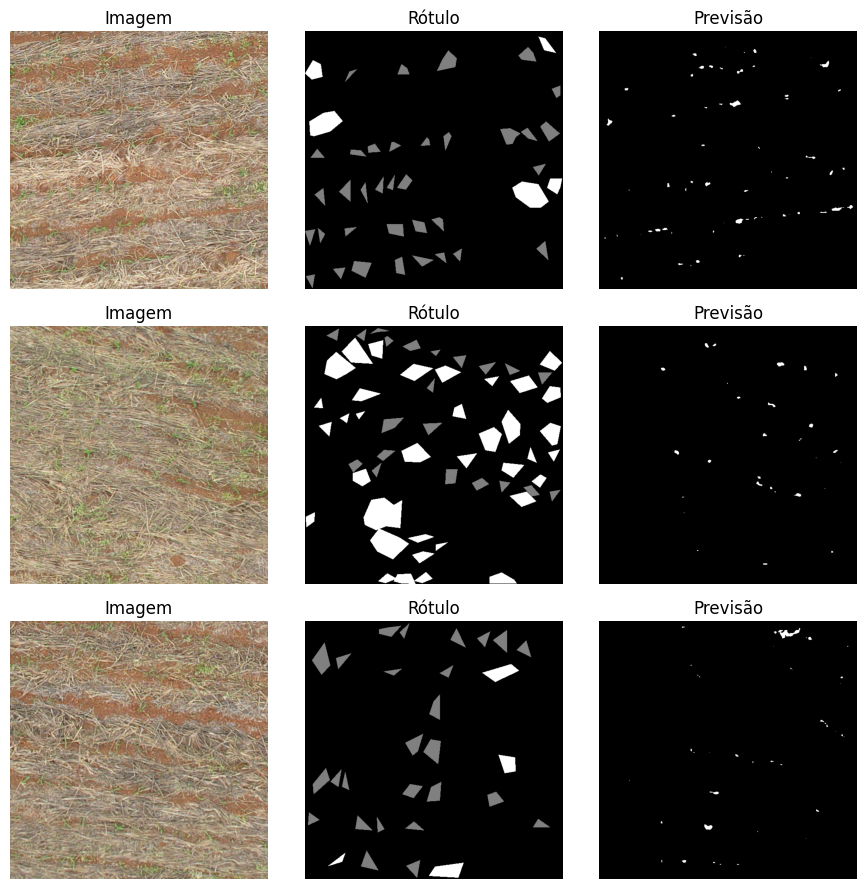

In [12]:
plotImagens(images, semantics, predicts)

In [13]:
def ajustarImages():
    rgb_path = 'data/rgb'
    rootatual = 'data/images'
    os.makedirs(rgb_path, exist_ok=True) 
    for image_path,image_name in [(os.path.join(rootatual,image_name),image_name) for image_name in os.listdir(rootatual) if image_name.endswith('png')]:
        image = cv2.imread(image_path,cv2.IMREAD_COLOR_RGB)
        r,g,b = cv2.split(image)
        print(cv2.imwrite(os.path.join(rgb_path,image_name.replace('image.','image_R.')),r))
        cv2.imwrite(os.path.join(rgb_path,image_name.replace('image.','image_G.')),g)
        cv2.imwrite(os.path.join(rgb_path,image_name.replace('image.','image_B.')),b)
# ajustarImages()

* Criando dataset/dataloader de validacao 

In [14]:
dataset_path = r'data\nao_temporal'
dataset_size = get_lenData('val')
# dataset_size = None
in_bands = 3
num_classes = 3
is_training = False
split = 'val'
augmentation = True
dataset_val = WeedsGaloreDataset( dataset_path, dataset_size, in_bands, num_classes, is_training, split, augmentation)
num_classes = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use: {device.type}')
model = deeplabv3plus_resnet50(num_classes=num_classes)
model = model.to(device)

model.backbone.conv1 = nn.Conv2d(num_classes,model.backbone.conv1.out_channels,kernel_size=7,stride=2,padding=3,bias=False,device=device)

model_weights_dir = actual_model()
model_dict = torch.load(model_weights_dir,map_location=device)
model.load_state_dict(model_dict)

# dataset
dataloader_val = DataLoader(dataset=dataset_val,batch_size=4,shuffle=False,num_workers=1,collate_fn=None, drop_last=True)
dataset_iter = iter(dataset)
dataset_val_iter = iter(dataset_val)
# mcce = MulticlassCalibrationError(num_classes=3, n_bins=3, norm='l1', ignore_index=None).to(device)
mcce = MulticlassCalibrationError(num_classes=3, n_bins=3, norm='l1', ignore_index=0).to(device)


Device in use: cpu


In [ ]:
def train(dataset_iter, device, net, evaluator, mcce, confmat):
    net.eval()
    for i, data in enumerate(dataset_iter):
        features, unique_labels, binary_labels = data
        features, unique_labels, binary_labels = (
            torch.tensor(features,dtype=torch.float32).to(device).unsqueeze(0),
            torch.tensor(unique_labels,dtype=torch.long).to(device),
            torch.tensor(binary_labels,dtype=torch.long).to(device),
        )
        labels = binary_labels
        # print("Formato da entrada:", features.shape)
        # print('type entrada:',type(features))
        # Forward pass
        out = net(features).detach()
        out = torch.nn.functional.softmax(out, dim=1)
        _, pred = torch.max(out, 1)

        # Atualiza métricas
        # print(f"Preds shape: {pred.shape}, Target shape: {labels.shape}")
        # evaluator.update(out.squeeze(0), labels)
        evaluator.update(out, labels)
        scene_scores = evaluator(pred, labels)
        mcce.update(out, labels)
        confmat.update(pred, labels)
    
    return scene_scores, net  # Retorna as métricas e o modelo atualizado

def validate(dataset_val_iter, device, net, evaluator, mcce, confmat):
    net.eval()

    evaluator.reset()  # Limpa as métricas anteriores
    mcce.reset()
    confmat.reset()

    all_scene_scores = []  # Lista para armazenar os scores de cada batch

    for i, data in enumerate(dataset_val_iter):
        features, unique_labels, binary_labels = data
        features, unique_labels, binary_labels = (
            torch.tensor(features,dtype=torch.float32).to(device).unsqueeze(0),
            torch.tensor(unique_labels,dtype=torch.long).to(device),
            torch.tensor(binary_labels,dtype=torch.long).to(device),
        )
        labels = binary_labels
        # print("Formato da entrada:", features.shape)
        # print('type entrada:',type(features))

        with torch.no_grad():  # Desliga o autograd para economia de memória
            out = net(features).detach()

        out = torch.nn.functional.softmax(out, dim=1)
        _, pred = torch.max(out, 1)

        # Atualiza os avaliadores
        print(f"Preds shape: {pred.shape}, Target shape: {labels.shape}")

        evaluator.update(out, labels)
        mcce.update(out, labels)  # Correção do erro de digitação
        confmat.update(pred, labels)

        # Obtém os scores do batch e adiciona à lista
        scene_scores = evaluator(pred, labels)
        all_scene_scores.append(scene_scores)

    # Calcula a média dos scores de todos os batches
    avg_scores = torch.stack(all_scene_scores).mean(dim=0)
    
    return avg_scores




In [26]:
num_epoch = 5
scores_train = []
scores_val = []
# print(batch_size)
for epoch in range(num_epoch):
    scores_t, model = train(dataset_iter, device, model, evaluator, mcce, confmat)
    scores_v = validate(dataset_val_iter, device, model, evaluator, mcce, confmat)

    scores_train.append(scores_t)
    scores_val.append(scores_v)

    # Exibir os resultados formatados
    print(f"\n{'=' * 40}")
    print(f"{'Overall scores (Epoch ' + str(epoch + 1) + ')':^40}")
    print(f"{'=' * 40}")
    print(f"{'Train':^18} | {'Val':^18}")
    print("-" * 40)
    print(f"mIoU: {scores_t.mean() * 100:.2f}% | {scores_v.mean() * 100:.2f}%")
    print(f"iou bg: {scores_t[0] * 100:.2f}% | {scores_v[0] * 100:.2f}%")
    print(f"iou crop: {scores_t[1] * 100:.2f}% | {scores_v[1] * 100:.2f}%")

    for weed_idx in range(2, len(scores_t)):
        print(f"iou weed_{weed_idx-1}: {scores_t[weed_idx] * 100:.2f}% | {scores_v[weed_idx] * 100:.2f}%")

    print(f"ECE: {mcce.compute()} | {mcce.compute()}")  # ECE é recalculado


ValueError: If `preds` have one dimension more than `target`, `preds.shape[1]` should be equal to number of classes.